#  Bài tâp về mạng tích chập

Trong bài này, chúng ta sẽ xây dựng một mạng tích chập sử dụng torch và thử train&test với tập MNIST nhé.


## Tổng quan một mạng CNN cơ bản

![CNN](http://personal.ie.cuhk.edu.hk/~ccloy/project_target_code/images/fig3.png)

## MNIST dataset

Trong bài tập này, chúng ta sẽ sử dựng tập MNIST rất nổi tiếng vể  các chữ số viết tay từ 0->9. Tập dataset này bao gồm 60000 ảnh cho training và 10000 ảnh cho testing. Các bức ảnh này đều đã được căn giữa và chỉnh với kích thước cố định là 28x28.

Trong phần tiền xử lý, chúng ta sẽ cần chuẩn hóa các giá trị pixel của mỗi ảnh về khoảng [0,1], kiểu dữ liệu sẽ là float32

<!-- ![MNIST Dataset](http://neuralnetworksanddeeplearning.com/images/mnist_100_digits.png) -->

Chi tiết tại: http://yann.lecun.com/exdb/mnist/

# Some configs

- Chúng ta sẽ setup một số hyper-parameters cũng như một số giá trị cần dùng theo hướng dẫn nhé
- Ở đây, mình muốn các bạn sử dụng Cuda, hãy vào runtime, rồi change the runtime type sang GPU nhé 

In [1]:
# Trước hết, chúng ta import một số thư viện cần thiết đã
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import random

In [3]:
# Số classes trong tập MNIST
num_classes = 10

# Số epoch 
epochs = 2

# Các tham số cần thiết cho quá trình traning.
learning_rate = 0.001
batch_size = 128
display_step = 50

# Path lưu best model 
checkpoint = 'model.pth'

# device chúng ta dùng cuda
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)


Using device: cpu


# Dataloader


In [4]:
# Transform image 
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
    ])

# load dataset từ torchvision.datasets
train_dataset = datasets.MNIST('../data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('../data', train=False, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size)

# Model

- Trong bài này, chúng ta sẽ định nghĩa một class Net, nó sẽ có cấu trúc như hình ở đầu notebook
- Bạn hãy chỉnh các tham số cho phù hợp nhé :) 

In [5]:
class Net(nn.Module):
  def __init__(self):
    super(Net,self).__init__()
    self.dropout = nn.Dropout()
    self.relu = nn.ReLU()
    self.conv1 = nn.Conv2d(1, 32, 3, 1)
    self.maxpool1 = nn.MaxPool2d(2)
    self.conv2 = nn.Conv2d(32, 64, 3, 1)
    self.maxpool2 = nn.MaxPool2d(2)
    self.conv3 = nn.Conv2d(64, 128, 3, 1)
    self.maxpool3 = nn.MaxPool2d(2)
    self.fc1 = nn.Linear(128, 256)
    self.fc2 = nn.Linear(256, 64)
    self.fc3 = nn.Linear(64, num_classes)

  def forward(self, x):
    x = self.relu(self.conv1(x))
    x = self.maxpool1(x)
    x = self.relu(self.conv2(x))
    x = self.maxpool2(x)
    x = self.relu(self.conv3(x))
    x = self.maxpool3(x)
    x = self.dropout(x)
    x = x.view(x.size(0), -1)
    x = self.relu(self.fc1(x))
    x = self.dropout(x)
    x = self.relu(self.fc2(x))
    x = self.fc3(x)
    return x

In [6]:
# call model, đừng quên set device nhé
model = Net().to(device)

# load lại pretrained model (nếu có)
try:
  model.load_state_dict(torch.load(checkpoint))
except:
  print("!!! Hãy train để có checkpoint file")

!!! Hãy train để có checkpoint file


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
best_val_loss = 999

for epoch in range(1, epochs):
    # Quá trình training 
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % display_step == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tTrain Loss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))
    # Quá trình testing 
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            output = F.log_softmax(output, dim=1)
            test_loss += criterion(output, target)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(test_loader.dataset)
    if test_loss < best_val_loss:
      best_val_loss = test_loss
      torch.save(model.state_dict(), checkpoint)
      print("***********    TEST_ACC = {}%    ***********".format(correct))

Train Epoch: 1 [0/60000 (0%)]	Train Loss: 2.300008
Train Epoch: 1 [6400/60000 (11%)]	Train Loss: 1.152817
Train Epoch: 1 [12800/60000 (21%)]	Train Loss: 0.825984
Train Epoch: 1 [19200/60000 (32%)]	Train Loss: 0.397828
Train Epoch: 1 [25600/60000 (43%)]	Train Loss: 0.368932
Train Epoch: 1 [32000/60000 (53%)]	Train Loss: 0.354367
Train Epoch: 1 [38400/60000 (64%)]	Train Loss: 0.370467
Train Epoch: 1 [44800/60000 (75%)]	Train Loss: 0.268569
Train Epoch: 1 [51200/60000 (85%)]	Train Loss: 0.260351
Train Epoch: 1 [57600/60000 (96%)]	Train Loss: 0.239001
***********    TEST_ACC = 9656%    ***********


In [8]:
# load lại model đã train
model.load_state_dict(torch.load(checkpoint))
# Set eval phase nhé bạn
model.eval()

Net(
  (dropout): Dropout(p=0.5, inplace=False)
  (relu): ReLU()
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (maxpool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=128, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

In [9]:
item = iter(test_loader)

In [10]:
data,target = next(item) # lấy một batch ra

In [11]:
test_idx = random.choice(range(len(data))) # lấy index của một phần tử của một batch

In [12]:
data = data[test_idx]
target = target[test_idx]
assert data.shape == (1,28,28)

In [13]:
# thử predict 

def plot(data, model):
  data = torch.unsqueeze(data, dim=0).to(device)
  output = model(data)
  output = F.log_softmax(output, dim=1)
  pred = output.argmax(dim=1, keepdim=True)
  print("Predict Number : ", pred[0][0].detach().cpu().numpy()) 
  plt.imshow(data[0][0].detach().cpu().numpy(), cmap='gray') 
  plt.show()

Predict Number :  7


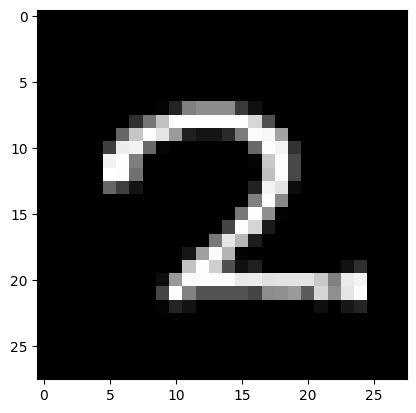

In [15]:
plot(data,model)